In [2]:
import pandas as pd
df=pd.read_csv("retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
df.shape

(1000, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [5]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


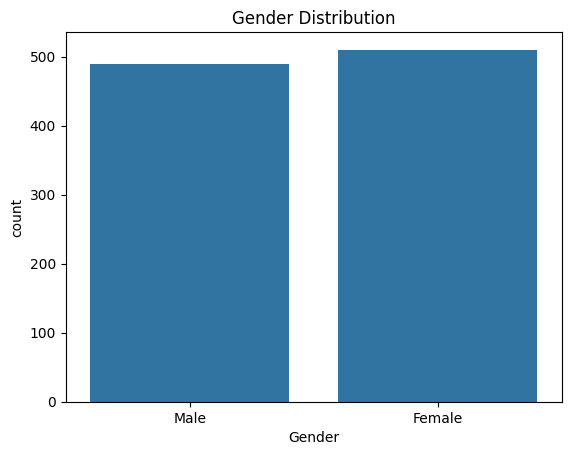

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='Gender',data=df)
plt.title("Gender Distribution")
plt.savefig("images/gender_distribution.png")
plt.show()

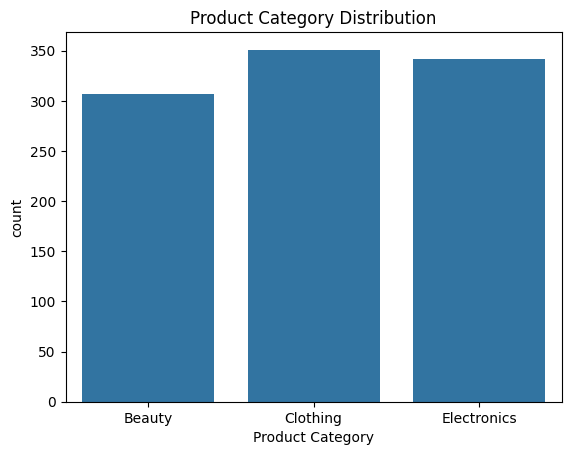

In [9]:
sns.countplot(x='Product Category', data=df)

plt.title("Product Category Distribution")
plt.savefig("images/sales_by_category.png")
plt.show()

**Age Distribution**

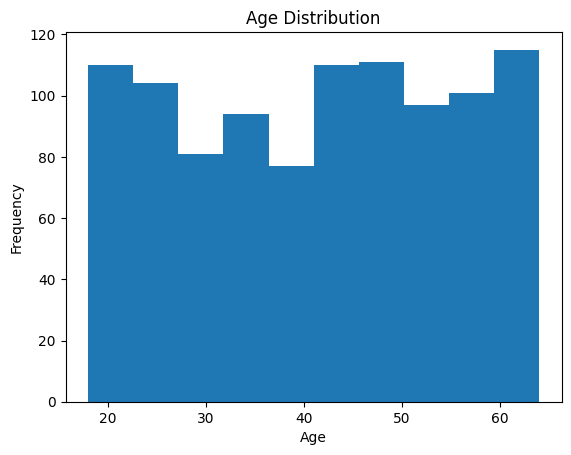

In [10]:
plt.hist(df['Age'], bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.savefig("images/age_distribution.png")
plt.show()

**convert date column**

In [13]:
df['Date']=pd.to_datetime(df['Date'])


**Monthly sales trend**

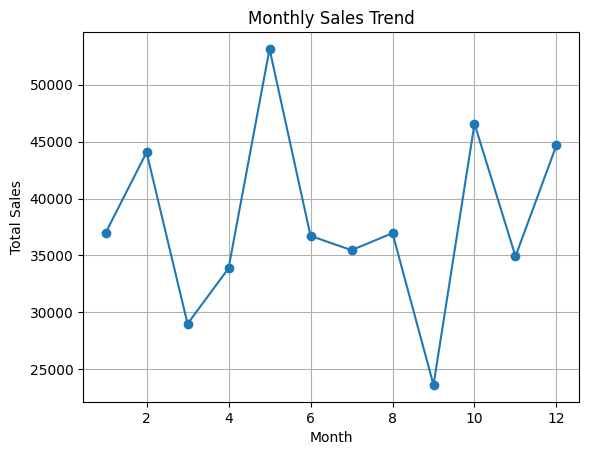

In [14]:

df['Month'] = df['Date'].dt.month

monthly_sales = df.groupby('Month')['Total Amount'].sum()

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.grid(True)
plt.savefig("images/monthly_sales.png")
plt.show()

**Sales by product category**

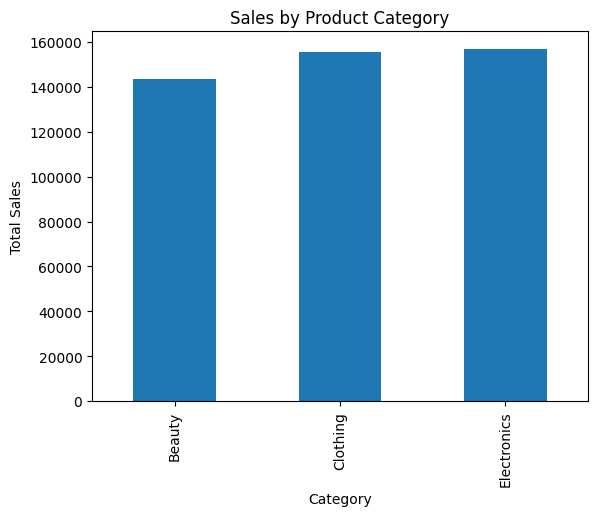

In [15]:
product_sales = df.groupby('Product Category')['Total Amount'].sum()

product_sales.plot(kind='bar')

plt.title('Sales by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.savefig("images/sales_by_product_category.png")
plt.show()

**Top 10 Customers**

In [16]:
top_customers = df.groupby('Customer ID')['Total Amount'].sum()

top_customers.sort_values(ascending=False).head(10)

Customer ID
CUST015    2000
CUST412    2000
CUST970    2000
CUST547    2000
CUST281    2000
CUST416    2000
CUST420    2000
CUST927    2000
CUST447    2000
CUST342    2000
Name: Total Amount, dtype: int64

**quantity sold by categor**y

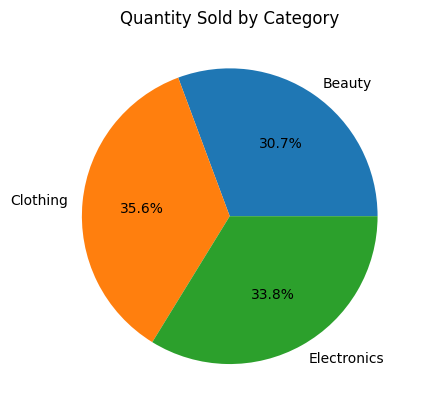

In [17]:
quantity = df.groupby('Product Category')['Quantity'].sum()

quantity.plot(kind='pie', autopct='%1.1f%%')

plt.title('Quantity Sold by Category')

plt.ylabel('')
plt.savefig("images/quantity_sold_by_category.png")
plt.show()

**correlation Heatmap**

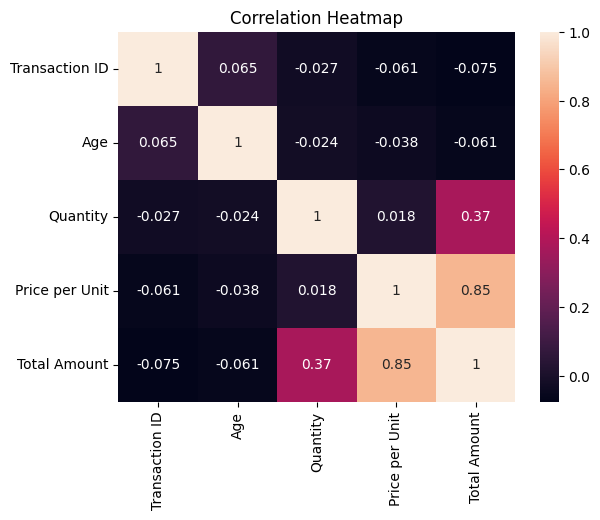

In [18]:
numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(), annot=True)

plt.title("Correlation Heatmap")
plt.savefig("images/correlation_heatmap.png")
plt.show()

**Buisiness Insights**

1. Beauty, Clothing and Electronics contribute significantly to total sales.

2. Monthly sales vary across the year, indicating seasonal purchasing patterns.

3. Customers from different age groups show varying purchasing behavior.

4. A small group of customers generates a large portion of total revenue.

5. Total Amount is positively correlated with Quantity purchased.

**Recommendations**

1. Increase inventory for high-performing categories.

2. Introduce loyalty programs for repeat customers.

3. Run promotions during lower sales months.

4. Use customer demographics for targeted marketing.

5. Focus advertising efforts on top-selling product categories.